In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, random_split, DataLoader
import sys
import re
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
torch.set_default_dtype(torch.float32)
torch.set_default_device(device)
generator = torch.Generator(device=device)

Using mps device


In [2]:
def create_datapoint(line_params, pos_params, neg_params, noise=0):
    """
    Input: 
        params: <w0, w1, w2> pos_num neg_num
    """
    try:
        # Read in params from input
        w0 = float(line_params[0])
        w1 = float(line_params[1])
        w2 = float(line_params[2])
        pos_num = int(pos_params)
        neg_num = int(neg_params)
    except:
        print("Input with wrong format")
        return
    else:
        # Initialize the line
        line = np.array([w1, w2 ,w0])

    # Create dataset
    pos_cnt = 0
    neg_cnt = 0
    pos_point = []
    neg_point = []
    while(pos_cnt < pos_num or neg_cnt < neg_num):
        point = np.round(np.random.random(2)*200-100, 2)
        vec = np.append(point, 1)
        val = np.sign(vec.dot(line))

        if val < 0 and neg_cnt < neg_num:
            neg_point.append(point)
            neg_cnt += 1

        elif val > 0 and pos_cnt < pos_num:
            pos_point.append(point)
            pos_cnt += 1
    
    # Add label to the dataset
    pos_point = np.array(pos_point)
    pos_label = np.zeros(pos_num)+1
    pos = np.c_[pos_point, pos_label]

    neg_point = np.array(neg_point)
    neg_label = np.zeros(neg_num)-1
    neg = np.c_[neg_point, neg_label]
    
    train = np.concatenate((pos, neg), axis=0)
    for i in range(noise):
        idx = np.random.randint(0, pos_num+neg_num)
        train[idx][2] *= -1
    
    # Save the dataset
    np.savetxt("train.txt", train, delimiter=",", fmt='%.2f')
    print("Create datapoint program finished")


In [3]:
args   = [(3, 4, 5), 1000, 1000, 200]
create_datapoint(args[0], args[1], args[2], args[3])
!ls

Create datapoint program finished
adaline_perceptron.ipynb perceptron.ipynb         readme.md
knowledge.md             perceptron_pro.ipynb     train.txt


(2000, 3)


Text(0.5, 1.0, 'Scatter plot')

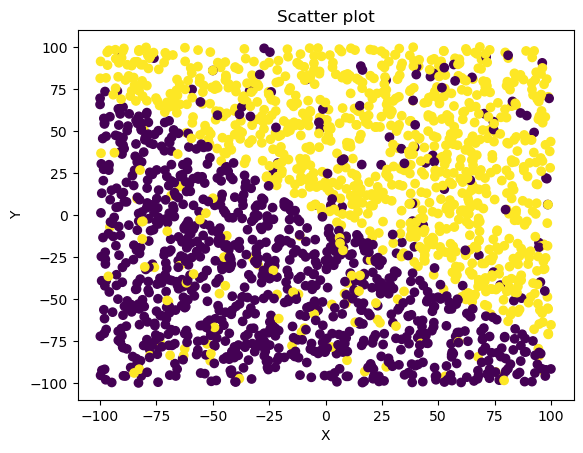

In [4]:
with open('train.txt', mode='r') as f:
    text_list = f.readlines()
#print(text_list[4])
data = []
for line in text_list:
    data.append( np.array(line.strip().split(','), dtype=np.float32) )
    #data.append(line.strip().split(',')) # remove blanks at both ends of a string
data_set_np = np.array(data)
# data_set = torch.tensor(data_set_np) # trans list to torch.tensor
N = len(data_set_np)
# data_set_cpu = data_set.cpu().numpy() # trans torch.tensor to numpy array
print(data_set_np.shape)

plt.scatter(data_set_np[:, 0], data_set_np[:, 1], c=data_set_np[:, 2], cmap='viridis')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter plot')


In [5]:
class MyDataset(Dataset):
  def __init__(self,data_set_np):
    self.data = torch.tensor(data_set_np)# header could be =none
    pass

  def __len__(self):
    return len(self.data)

  def __getitem__(self, index):
    # x -> y
    x0 = torch.tensor([1.0])
    x = self.data[index, 0:2]
    x = torch.cat([x0, x], dim=0)
    y = self.data[index, 2]

    # return label, image data tensor and target tensor
    return x, y

my_data = MyDataset(data_set_np)

subsetA, subsetB = random_split(my_data, [0.8, 0.2], generator=generator)
print(f"length of subsetA: {len(subsetA)}")
print(f"length of subsetB: {len(subsetB)}")
subsetA[-1][0]

length of subsetA: 1600
length of subsetB: 400


tensor([  1.0000,  60.1200, -99.6300], device='mps:0')

In [6]:
train_loader = DataLoader(subsetA, batch_size=len(subsetA))
test_loader = DataLoader(subsetB, batch_size=len(subsetB))

# Extract the full tensors in one line using next(iter(...))
X_train, y_train = next(iter(train_loader))
X_test, y_test = next(iter(test_loader))


In [7]:
X_train.size() 
y_train.size()

torch.Size([1600])

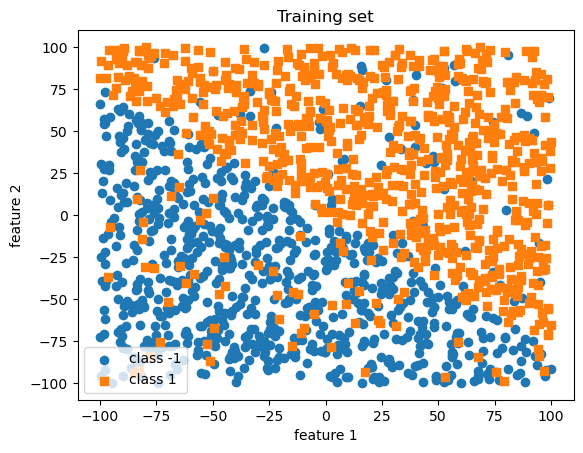

In [8]:
plt.scatter(X_train.cpu()[y_train.cpu()==-1, 1], X_train.cpu()[y_train.cpu()==-1, 2], label='class -1', marker='o')
plt.scatter(X_train.cpu()[y_train.cpu()==1, 1], X_train.cpu()[y_train.cpu()==1, 2], label='class 1', marker='s')
plt.title('Training set')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend()
plt.show()

In [ ]:
class Adaline1():
    def __init__(self, num_features):
        self.num_features = num_features
        self.weights = torch.zeros(num_features)

    def forward(self, x):
        netinputs = torch.matmul(x, self.weights)
        activations = netinputs
        return activations
    def loss(self, yhat, y):
        return torch.mean((yhat - y)**2)

    def backward(self, x, yhat, y):

        grad_loss_yhat = 2*(yhat - y)

        grad_yhat_weights = x

        # Chain rule: inner times outer
        grad_loss_weights = torch.matmul(grad_yhat_weights.t(),
                                         grad_loss_yhat) / y.size(0)

        # return negative gradient
        return (-1)*grad_loss_weights
    def train(self, x, y, num_epochs,
          learning_rate=1e-5, seed=123, minibatch_size=10):
        cost = []
        for e in range(num_epochs):
            #### Shuffle epoch
            shuffle_idx = torch.randperm(y.size(0), dtype=torch.long)
            minibatches = torch.split(shuffle_idx, minibatch_size)

            for minibatch_idx in minibatches:

                #### Compute outputs ####
                yhat = self.forward(x[minibatch_idx])
                #### Compute gradients ####
                negative_grad_w = self.backward(x[minibatch_idx], yhat, y[minibatch_idx])
                
                #### Update weights ####
                self.weights += learning_rate * negative_grad_w
                
                #### Logging ####
                minibatch_loss = self.loss(yhat, y[minibatch_idx])
                print('    Minibatch MSE: %.3f' % minibatch_loss)
        #### Logging ####
        yhat = self.forward(x)
        curr_loss = self.loss(yhat, y)
        print('Epoch: %03d' % (e+1), end="")
        print(' | MSE: %.5f' % curr_loss)
        cost.append(curr_loss)
        
        return cost

    def evaluate(self, x, y):
        # Convert continuous predictions to binary outputs (+1 / -1) for classification accuracy
        predictions = torch.where(self.forward(x) > 0.0, 1.0, -1.0)
        accuracy = torch.sum(predictions == y).float() / y.shape[0]
        return accuracy
ppn = Adaline1(num_features=3)

ppn.train(X_train, y_train, num_epochs=10)

print('Model parameters:')
print('  Weights: %s' % ppn.weights)
print(f"accuracy on test set: {ppn.evaluate(X_test, y_test):.4f}")

    Minibatch MSE: 1.000
    Minibatch MSE: 0.902
    Minibatch MSE: 0.839
    Minibatch MSE: 0.939
    Minibatch MSE: 0.800
    Minibatch MSE: 0.745
    Minibatch MSE: 0.632
    Minibatch MSE: 0.532
    Minibatch MSE: 0.710
    Minibatch MSE: 0.945
    Minibatch MSE: 0.633
    Minibatch MSE: 0.653
    Minibatch MSE: 0.653
    Minibatch MSE: 0.759
    Minibatch MSE: 0.764
    Minibatch MSE: 0.518
    Minibatch MSE: 0.541
    Minibatch MSE: 0.421
    Minibatch MSE: 0.672
    Minibatch MSE: 0.395
    Minibatch MSE: 0.573
    Minibatch MSE: 0.575
    Minibatch MSE: 0.418
    Minibatch MSE: 0.914
    Minibatch MSE: 0.303
    Minibatch MSE: 0.393
    Minibatch MSE: 0.744
    Minibatch MSE: 0.310
    Minibatch MSE: 0.384
    Minibatch MSE: 0.736
    Minibatch MSE: 0.392
    Minibatch MSE: 0.258
    Minibatch MSE: 0.405
    Minibatch MSE: 0.487
    Minibatch MSE: 0.801
    Minibatch MSE: 0.348
    Minibatch MSE: 0.462
    Minibatch MSE: 0.264
    Minibatch MSE: 0.531
    Minibatch MSE: 0.339


In [10]:
# a1 = torch.randn(3)
# a2 = X_test[0]
# print(f"{a1}, {a2} and {a1@a2}")
# torch.mm(a1.reshape(1,-1),a2.reshape(-1,1))

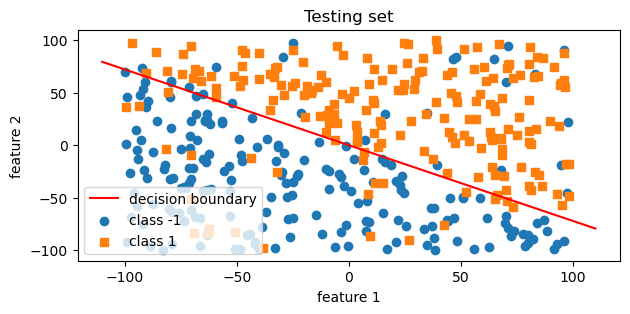

In [11]:
w = ppn.weights.cpu()

x0_min = -110
x1_min = ( (-(w[1] * x0_min) - w[0])
          / w[2] )

x0_max = 110
x1_max = ( (-(w[1] * x0_max) - w[0])
          / w[2] )

fig, ax = plt.subplots( figsize=(7, 3))

ax.plot([x0_min, x0_max], [x1_min, x1_max], c='r', label='decision boundary')


plt.scatter(X_test.cpu()[y_test.cpu()==-1, 1], X_test.cpu()[y_test.cpu()==-1, 2], label='class -1', marker='o')
plt.scatter(X_test.cpu()[y_test.cpu()==1, 1], X_test.cpu()[y_test.cpu()==1, 2], label='class 1', marker='s')
plt.title('Testing set')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend()
plt.show()